# SBench KDD Apriori Execution

This notebook executes the data-mining and evaluation stages of the SBench KDD workflow. It consumes the existing `results.sqlite` database, groups `execution_items` into transactions, runs Apriori with `mlxtend`, generates association rules, and optionally exports the results.


## 1. Configuration

Tune these parameters for each KDD execution. Record the chosen values with the exported outputs.


In [201]:
from __future__ import annotations

import json
import sqlite3
import warnings
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

MIN_SUPPORT = 0.1
MIN_CONFIDENCE = 0.50
MIN_LIFT = 1.00
MAX_ITEMSET_SIZE = 3
DROP_UNIVERSAL_ITEMS = True


In [202]:
def find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / 'sbench').is_dir() and (path / 'results.sqlite').exists():
            return path
    raise FileNotFoundError('Could not find repo root containing sbench/ and results.sqlite')


REPO_ROOT = find_repo_root(Path.cwd())
DATABASE_PATH = REPO_ROOT / 'results.sqlite'
DATABASE_URI = DATABASE_PATH.resolve().as_uri() + '?mode=ro'
EXECUTION_ID = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')
OUTPUT_DIR = REPO_ROOT / 'notebooks' / 'kdd_apriori_outputs' / EXECUTION_ID

REPO_ROOT, DATABASE_PATH, OUTPUT_DIR


(PosixPath('/Users/douglas/code/masters/sbench'),
 PosixPath('/Users/douglas/code/masters/sbench/results.sqlite'),
 PosixPath('/Users/douglas/code/masters/sbench/notebooks/kdd_apriori_outputs/20260619T012624Z'))

## 2. Load Transactions

Each `execution_id` becomes one Apriori transaction. Each row in `execution_items` becomes one categorical item in that transaction.


In [203]:
with sqlite3.connect(DATABASE_URI, uri=True) as connection:
    connection.row_factory = sqlite3.Row
    execution_rows = list(connection.execute('SELECT * FROM executions ORDER BY execution_id'))
    item_rows = list(connection.execute('SELECT execution_id, item FROM execution_items ORDER BY execution_id, item'))

transactions_by_execution: dict[str, set[str]] = {}
for row in item_rows:
    transactions_by_execution.setdefault(row['execution_id'], set()).add(row['item'])

transaction_ids = sorted(transactions_by_execution)
transactions = [sorted(transactions_by_execution[execution_id]) for execution_id in transaction_ids]

dataset_summary = {
    'execution_count': len(execution_rows),
    'transaction_count': len(transactions),
    'transaction_item_count': len(item_rows),
    'harness_counts': dict(Counter(row['harness'] for row in execution_rows)),
    'track_counts': dict(Counter(row['track'] for row in execution_rows)),
    'status_counts': dict(Counter(row['status'] for row in execution_rows)),
    'deliverables_present_counts': dict(Counter(str(row['deliverables_present']) for row in execution_rows)),
    'parameters': {
        'algorithm': 'mlxtend.frequent_patterns.apriori',
        'transaction_encoder': 'mlxtend.preprocessing.TransactionEncoder',
        'min_support': MIN_SUPPORT,
        'min_confidence': MIN_CONFIDENCE,
        'max_itemset_size': MAX_ITEMSET_SIZE,
        'drop_universal_items': DROP_UNIVERSAL_ITEMS,
    },
}
dataset_summary


{'execution_count': 63,
 'transaction_count': 63,
 'transaction_item_count': 735,
 'harness_counts': {'bdi': 21, 'codex': 21, 'opencode': 21},
 'track_counts': {'long_context': 9,
  'replanning': 9,
  'recovery': 9,
  'smoke': 27,
  'distractor_goal': 9},
 'status_counts': {'success': 63},
 'deliverables_present_counts': {'1': 63},
 'parameters': {'algorithm': 'mlxtend.frequent_patterns.apriori',
  'transaction_encoder': 'mlxtend.preprocessing.TransactionEncoder',
  'min_support': 0.1,
  'min_confidence': 0.5,
  'max_itemset_size': 3,
  'drop_universal_items': True}}

## 3. Encode And Inspect Transactions

`mlxtend` expects a one-hot encoded table where each row is a transaction and each boolean column is an item. Universal items are useful diagnostics, but they do not distinguish executions, so the mining frame drops them by default.


In [204]:
encoder = TransactionEncoder()
encoded_transactions = encoder.fit(transactions).transform(transactions) if transactions else []
transaction_frame = pd.DataFrame(encoded_transactions, columns=encoder.columns_)
transaction_frame.index = transaction_ids

item_support = transaction_frame.mean().sort_values(ascending=False) if not transaction_frame.empty else pd.Series(dtype=float)
universal_items = item_support[item_support >= 1.0].index.tolist()
mining_frame = transaction_frame.drop(columns=universal_items) if DROP_UNIVERSAL_ITEMS else transaction_frame

dataset_summary.update({
    'encoded_item_count': int(transaction_frame.shape[1]),
    'mining_item_count': int(mining_frame.shape[1]),
    'dropped_universal_items': universal_items,
})

item_support_frame = item_support.rename('support').reset_index().rename(columns={'index': 'item'})
item_support_frame.head(30)


,item,support
0,archived_files:3-5,1.000000
1,status:success,1.000000
2,deliverables:present,1.000000
3,tokens:available,1.000000
4,timeout:false,1.000000
5,cache_tokens:available,0.666667
6,elapsed:1-1.5m,0.492063
7,track:smoke,0.428571
8,token_total:10k-25k,0.412698
9,harness:bdi,0.333333


## 4. Run Apriori

`mlxtend.frequent_patterns.apriori` returns frequent itemsets with support. We add itemset size, support count, and a readable item string for reporting.


In [205]:
def format_itemset(itemset: frozenset[str]) -> str:
    return ' | '.join(sorted(itemset))


frequent_itemsets = apriori(
    mining_frame,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=MAX_ITEMSET_SIZE,
) if not mining_frame.empty else pd.DataFrame(columns=['support', 'itemsets'])

if frequent_itemsets.empty:
    frequent_itemsets_export = pd.DataFrame(columns=['items', 'size', 'support_count', 'support'])
else:
    frequent_itemsets = frequent_itemsets.assign(
        size=frequent_itemsets['itemsets'].map(len),
        support_count=(frequent_itemsets['support'] * len(mining_frame)).round().astype(int),
        items=frequent_itemsets['itemsets'].map(format_itemset),
    ).sort_values(['support', 'size', 'items'], ascending=[False, True, True]).reset_index(drop=True)
    frequent_itemsets_export = frequent_itemsets[['items', 'size', 'support_count', 'support']]

frequent_itemsets_export.head(20)


,items,size,support_count,support
0,cache_tokens:available,1,42,0.666667
1,elapsed:1-1.5m,1,31,0.492063
2,track:smoke,1,27,0.428571
3,token_total:10k-25k,1,26,0.412698
4,harness:bdi,1,21,0.333333
5,harness:codex,1,21,0.333333
6,harness:opencode,1,21,0.333333
7,llm_calls:1-2,1,21,0.333333
8,llm_calls:>5,1,21,0.333333
9,cache_tokens:available | elapsed:1-1.5m,2,21,0.333333


## 5. Generate Association Rules

Rules are filtered by confidence and lift. The readable export keeps the core metrics needed for evaluation.


In [206]:
rule_columns = ['antecedent', 'consequent', 'support_count', 'support', 'confidence', 'lift']

if frequent_itemsets.empty or not (frequent_itemsets['itemsets'].map(len) >= 2).any():
    rules_export = pd.DataFrame(columns=rule_columns)
else:
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=RuntimeWarning, module='mlxtend.frequent_patterns.association_rules')
        rules = association_rules(
            frequent_itemsets[['support', 'itemsets']],
            metric='confidence',
            min_threshold=MIN_CONFIDENCE,
        )
    rules = rules[rules['lift'] >= MIN_LIFT].copy()
    if rules.empty:
        rules_export = pd.DataFrame(columns=rule_columns)
    else:
        rules = rules.assign(
            antecedent=rules['antecedents'].map(format_itemset),
            consequent=rules['consequents'].map(format_itemset),
            support_count=(rules['support'] * len(mining_frame)).round().astype(int),
        ).sort_values(['lift', 'confidence', 'support'], ascending=[False, False, False]).reset_index(drop=True)
        rules_export = rules[rule_columns]

rules_export.head(20)


,antecedent,consequent,support_count,support,confidence,lift
0,track:long_context,task:clinic_rollout_plan,9,0.142857,1.000000,7.000000
1,task:clinic_rollout_plan,track:long_context,9,0.142857,1.000000,7.000000
2,task:community_workshop_replan,track:replanning,9,0.142857,1.000000,7.000000
3,track:replanning,task:community_workshop_replan,9,0.142857,1.000000,7.000000
4,task:grant_closeout_recovery,track:recovery,9,0.142857,1.000000,7.000000
5,track:recovery,task:grant_closeout_recovery,9,0.142857,1.000000,7.000000
6,task:shelter_restock_scope,track:distractor_goal,9,0.142857,1.000000,7.000000
7,track:distractor_goal,task:shelter_restock_scope,9,0.142857,1.000000,7.000000
8,elapsed:1-1.5m | task:grant_closeout_recovery,track:recovery,8,0.126984,1.000000,7.000000
9,elapsed:1-1.5m | track:recovery,task:grant_closeout_recovery,8,0.126984,1.000000,7.000000


## 6. Export Results

Run this cell after reviewing the outputs. The exported files represent one KDD execution.


In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with (OUTPUT_DIR / 'dataset_summary.json').open('w', encoding='utf-8') as file:
    json.dump(dataset_summary, file, indent=2, sort_keys=True)

frequent_itemsets_export.to_csv(OUTPUT_DIR / 'frequent_itemsets.csv', index=False)
rules_export.to_csv(OUTPUT_DIR / 'association_rules.csv', index=False)

evaluation_template = '''# KDD Apriori Evaluation Notes

## Parameters

- algorithm: {algorithm}
- transaction_encoder: {transaction_encoder}
- min_support: {min_support}
- min_confidence: {min_confidence}
- min_lift: {min_lift}
- max_itemset_size: {max_itemset_size}
- drop_universal_items: {drop_universal_items}

## Meaningful Rules

- TBD

## Trivial Or Misleading Rules

- TBD

## Dataset Limitations

- Current imported data may have limited variation in status and deliverable completion.
- Universal items were dropped before Apriori when `DROP_UNIVERSAL_ITEMS` was enabled.
'''.format(**dataset_summary['parameters'])

(OUTPUT_DIR / 'evaluation_notes.md').write_text(evaluation_template, encoding='utf-8')
OUTPUT_DIR


## 7. Visualize Rules

These visualizations use `rules_export` from step 5. Re-run steps 4 and 5 first after changing Apriori thresholds.


In [208]:
import matplotlib.pyplot as plt

EMPTY_RULE_MESSAGE = 'No association rules to visualize. Lower MIN_SUPPORT, MIN_CONFIDENCE, or MIN_LIFT and re-run steps 4-5.'
VISUALIZATION_EXCLUDED_ITEMS = sorted(set(globals().get('universal_items', []))) if globals().get('DROP_UNIVERSAL_ITEMS', False) else []
VISUALIZATION_EXCLUDED_ITEM_SET = set(VISUALIZATION_EXCLUDED_ITEMS)
EXCLUDE_FULL_SUPPORT_RULES = True
FULL_SUPPORT_TOLERANCE = 1e-12


def parse_item_group(item_group: str) -> list[str]:
    return [item.strip() for item in str(item_group).split(' | ') if item.strip()]


def has_visualization_excluded_item(item_group: str) -> bool:
    return bool(VISUALIZATION_EXCLUDED_ITEM_SET.intersection(parse_item_group(item_group)))


def get_rules_for_visualization(rules_frame: pd.DataFrame) -> pd.DataFrame:
    if rules_frame.empty:
        return rules_frame.copy()

    rules_viz = rules_frame.copy()
    for column in ['support', 'confidence', 'lift', 'support_count']:
        if column in rules_viz:
            rules_viz[column] = pd.to_numeric(rules_viz[column], errors='coerce')

    rules_viz = rules_viz.dropna(subset=['support', 'confidence', 'lift']).reset_index(drop=True)
    if VISUALIZATION_EXCLUDED_ITEM_SET:
        contains_excluded_item = (
            rules_viz['antecedent'].map(has_visualization_excluded_item)
            | rules_viz['consequent'].map(has_visualization_excluded_item)
        )
        filtered_count = int(contains_excluded_item.sum())
        rules_viz = rules_viz.loc[~contains_excluded_item].reset_index(drop=True)
        if filtered_count:
            print(f'Filtered {filtered_count} visualization rules containing universal items: {VISUALIZATION_EXCLUDED_ITEMS}')

    if EXCLUDE_FULL_SUPPORT_RULES:
        has_full_support = rules_viz['support'] >= 1.0 - FULL_SUPPORT_TOLERANCE
        filtered_count = int(has_full_support.sum())
        rules_viz = rules_viz.loc[~has_full_support].reset_index(drop=True)
        if filtered_count:
            print(f'Filtered {filtered_count} visualization rules with support 1.0')

    return rules_viz


rules_viz = get_rules_for_visualization(rules_export)
rules_viz


,antecedent,consequent,support_count,support,confidence,lift
0,track:long_context,task:clinic_rollout_plan,9,0.142857,1.000000,7.000000
1,task:clinic_rollout_plan,track:long_context,9,0.142857,1.000000,7.000000
2,task:community_workshop_replan,track:replanning,9,0.142857,1.000000,7.000000
3,track:replanning,task:community_workshop_replan,9,0.142857,1.000000,7.000000
4,task:grant_closeout_recovery,track:recovery,9,0.142857,1.000000,7.000000
...,...,...,...,...,...,...
240,llm_calls:>5 | token_total:10k-25k,elapsed:1-1.5m,9,0.142857,0.529412,1.075901
241,elapsed:1-1.5m,cache_tokens:available,21,0.333333,0.677419,1.016129
242,cache_tokens:available,elapsed:1-1.5m,21,0.333333,0.500000,1.016129
243,track:smoke,cache_tokens:available,18,0.285714,0.666667,1.000000


### 7.1 Support/Confidence Scatter

Each dot is a rule. X is support, Y is confidence, color is lift, and marker size scales by support count.


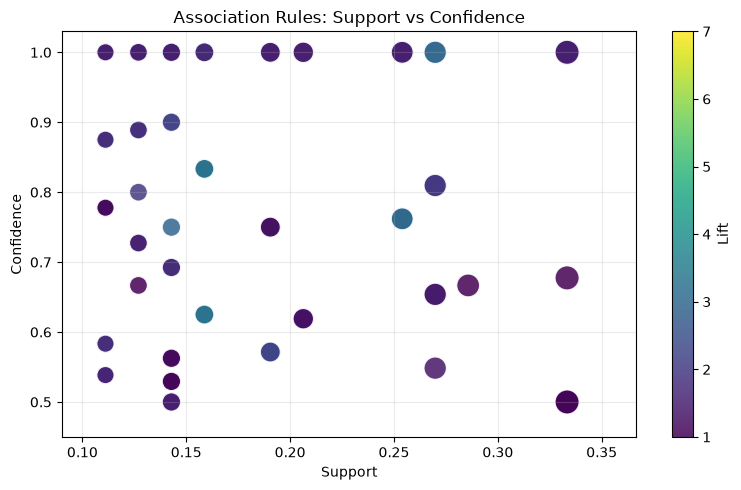

In [209]:
if rules_viz.empty:
    print(EMPTY_RULE_MESSAGE)
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    support_counts = rules_viz.get('support_count', pd.Series(1, index=rules_viz.index)).fillna(1).clip(lower=1)
    marker_sizes = 80 + (support_counts / support_counts.max()) * 220

    scatter = ax.scatter(
        rules_viz['support'],
        rules_viz['confidence'],
        c=rules_viz['lift'],
        s=marker_sizes,
        cmap='viridis',
        alpha=0.85,
        edgecolors='white',
        linewidths=0.8,
    )

    ax.set_title('Association Rules: Support vs Confidence')
    ax.set_xlabel('Support')
    ax.set_ylabel('Confidence')
    ax.set_xlim(0.09, min(1.0, max(0.05, rules_viz['support'].max() * 1.1)))
    ax.set_ylim(0.45, min(1.05, max(0.55, rules_viz['confidence'].max() * 1.03)))
    ax.grid(True, alpha=0.25)

    colorbar = fig.colorbar(scatter, ax=ax)
    colorbar.set_label('Lift')

    plt.tight_layout()
